# Day 13 – Machine Learning for Market Direction (EURUSD)

## Objective
Build a predictive model using engineered features to forecast next-day market direction.

## Goal
Use data-driven techniques to improve trading decision-making.

In [20]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
#Create Output Folder
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [23]:
file_path = r"C:\Users\THIS PC\quant-finance-portfolio\day-12-feature-engineering\outputs\tables\day12_feature_dataset.csv"
df = pd.read_csv(file_path, index_col=0)

df.head()

,return_lag_1,return_lag_2,return_lag_3,return_lag_5,rolling_mean_5,rolling_mean_10,rolling_std_5,rolling_std_10,momentum_3,momentum_5,momentum_10,high_low_range,open_close_range,SMA_ratio,RSI_14,MACD,target,simple_return,close
2007-02-13,-0.002999,-0.002684,0.002152,0.004254,0.000836,0.000529,0.003616,0.003712,-0.000230,0.004159,0.005243,0.006827,0.005476,1.001568,56.261682,0.001660,1,0.005476,1.3037
2007-02-14,0.005476,-0.002999,-0.002684,0.002234,0.001800,0.000741,0.004594,0.004038,0.009535,0.008992,0.007366,0.009521,0.006980,1.001571,66.836735,0.002625,1,0.007057,1.3129
2007-02-15,0.007057,0.005476,-0.002999,0.002152,0.001538,0.000917,0.004606,0.003996,0.013420,0.007669,0.009139,0.004033,0.000838,1.001804,69.296741,0.003439,0,0.000838,1.3140
2007-02-16,0.000838,0.007057,0.005476,-0.002684,0.002029,0.001355,0.004152,0.003537,0.007670,0.010150,0.013579,0.003958,-0.000228,1.002480,66.544118,0.004014,1,-0.000228,1.3137
2007-02-19,-0.000228,0.000838,0.007057,-0.002999,0.002902,0.001747,0.003174,0.003263,0.001980,0.014577,0.017559,0.003117,0.000685,1.003430,66.909091,0.004562,0,0.001370,1.3155


In [24]:
#Define features and Target
X = df.drop(columns=["target"])
y = df["target"]

In [25]:
#Train and Test Split
'''X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)'''
split_index = int(len(df) * 0.7)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 3486
Test size: 1495


In [26]:
#Train logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
#Make Prediction
y_pred = model.predict(X_test)

In [28]:
#Evaluate Prediction Quality
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5010033444816053


In [29]:
#Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5010033444816053

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.04      0.08       757
           1       0.50      0.97      0.66       738

    accuracy                           0.50      1495
   macro avg       0.55      0.51      0.37      1495
weighted avg       0.55      0.50      0.37      1495



In [30]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 34 723]
 [ 23 715]]


In [31]:
#Convert Prediction into Strategy
test_returns = df.loc[X_test.index, "simple_return"]

In [32]:
df["simple_return"] = df["close"].pct_change()
test_returns = df.loc[X_test.index, "simple_return"]

In [33]:
#Convert Prediction into Strategy
test_returns = df.loc[X_test.index, "simple_return"]

strategy_returns = y_pred * test_returns

ml_equity = (1 + strategy_returns).cumprod()
buy_hold = (1 + test_returns).cumprod()

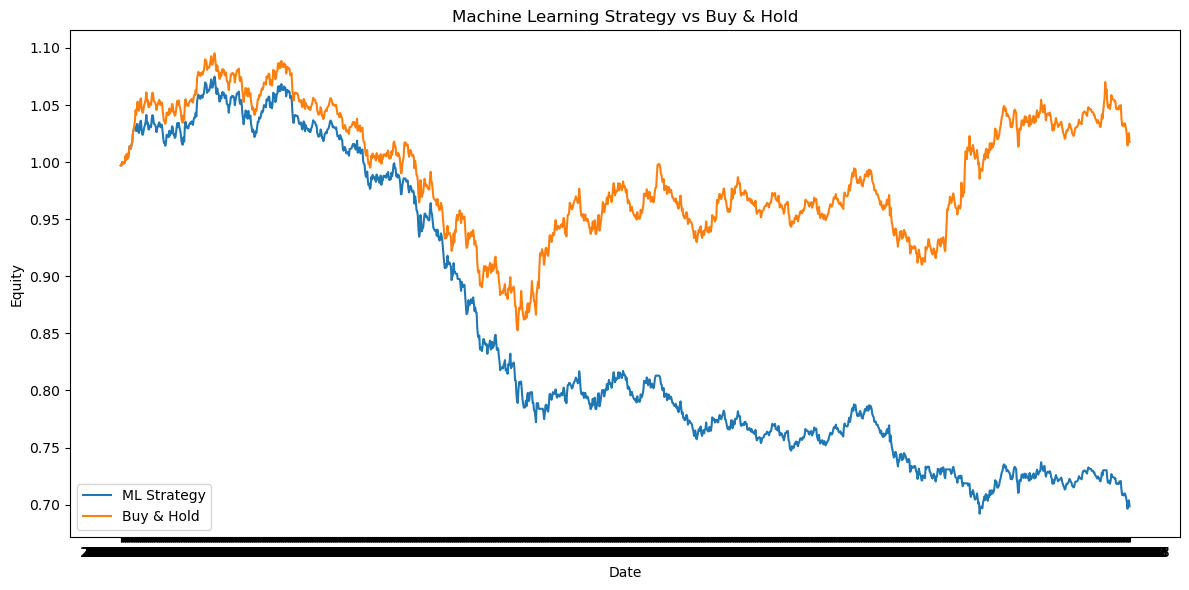

In [34]:
#Plot ML Strategy vs Buy-and-Hold
plt.figure(figsize=(12, 6))

plt.plot(ml_equity.index, ml_equity, label="ML Strategy")
plt.plot(buy_hold.index, buy_hold, label="Buy & Hold")

plt.title("Machine Learning Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/charts/day13_ml_vs_buyhold.png")
plt.show()

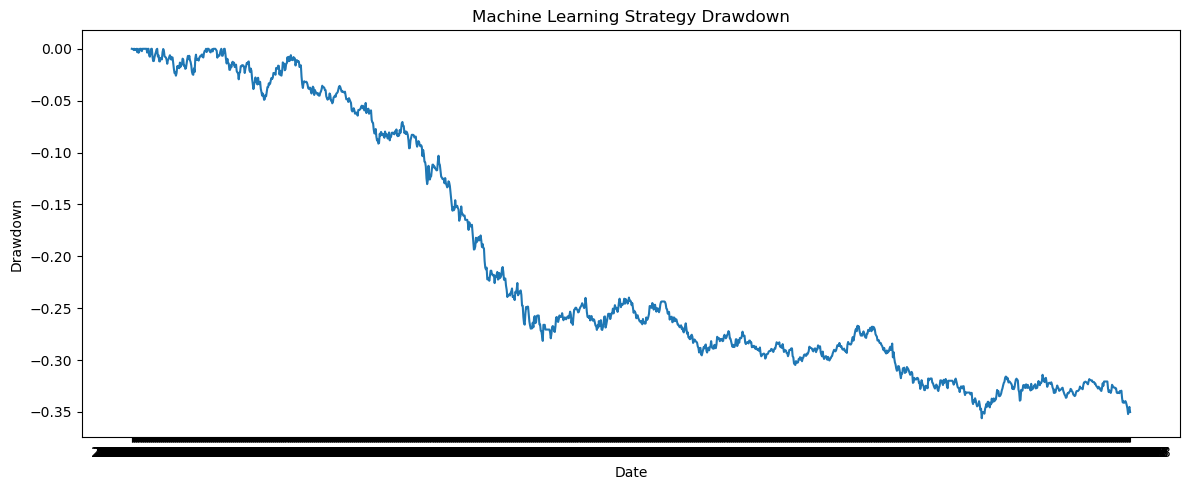

In [36]:
#DrawDown Analysis
rolling_max = ml_equity.cummax()
ml_drawdown = (ml_equity - rolling_max) / rolling_max

#Plot It
plt.figure(figsize=(12, 5))
plt.plot(ml_drawdown.index, ml_drawdown)

plt.title("Machine Learning Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.tight_layout()
plt.savefig("outputs/charts/day13_ml_drawdown.png")
plt.show()

In [37]:
#Compute Performance Metrics
total_return = ml_equity.iloc[-1] - 1
annual_return = strategy_returns.mean() * 252
annual_volatility = strategy_returns.std() * np.sqrt(252)
sharpe = annual_return / annual_volatility if annual_volatility != 0 else np.nan
max_drawdown = ml_drawdown.min()

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Total Return",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Value": [
        accuracy,
        total_return,
        annual_return,
        annual_volatility,
        sharpe,
        max_drawdown
    ]
})

metrics

,Metric,Value
0,Accuracy,0.501003
1,Total Return,-0.301520
2,Annual Return,-0.058184
3,Annual Volatility,0.067783
4,Sharpe Ratio,-0.858382
5,Max Drawdown,-0.356154


In [39]:
#Save Results
metrics.to_csv("outputs/tables/day13_metrics.csv", index=False)

#Save Prediction
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Return": test_returns,
    "Strategy_Return": strategy_returns
}, index=X_test.index)

predictions_df.to_csv("outputs/tables/day13_predictions.csv")
predictions_df.head()

,Actual,Predicted,Return,Strategy_Return
2020-06-25,0,1,-0.002764,-0.002764
2020-06-26,1,1,-0.000312,-0.000312
2020-06-29,0,1,0.002781,0.002781
2020-06-30,1,1,-0.001227,-0.001227
2020-07-01,0,1,0.001522,0.001522


In [40]:
#Features Importance Proxy (Co-efficient)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
15,MACD,0.107952
13,SMA_ratio,0.039369
3,return_lag_5,0.005938
14,RSI_14,0.000667
6,rolling_std_5,-0.015047
7,rolling_std_10,-0.017680
2,return_lag_3,-0.027526
17,close,-0.029453
5,rolling_mean_10,-0.089443
4,rolling_mean_5,-0.135188


In [41]:
#Save 
coef_df.to_csv("outputs/tables/day13_feature_coefficients.csv", index=False)

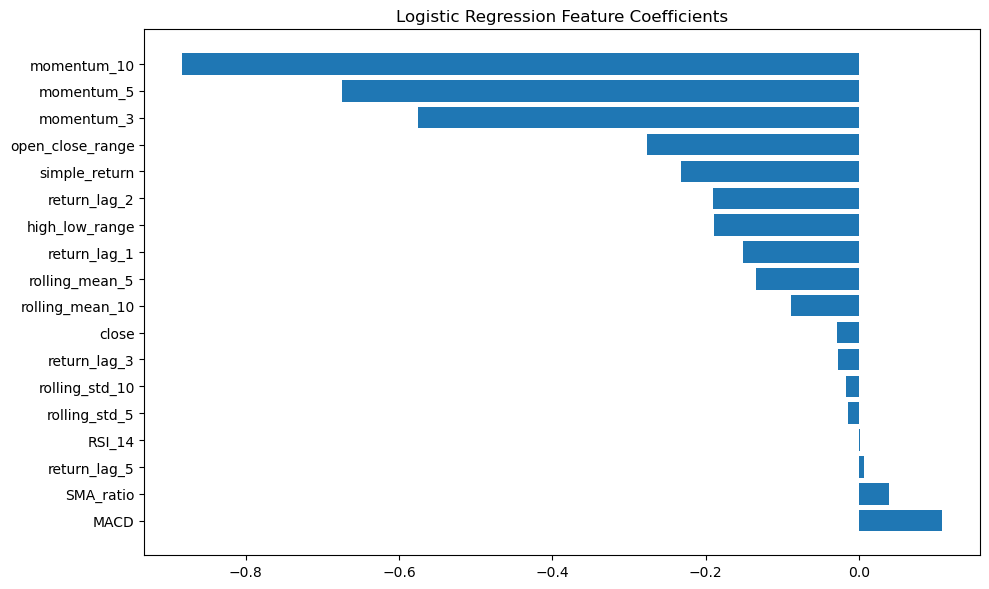

In [42]:
#Plot it
plt.figure(figsize=(10, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.savefig("outputs/charts/day13_feature_coefficients.png")
plt.show()